<a href="https://colab.research.google.com/github/DawidSkowronski/PyTorch-Projects/blob/main/PyTorch_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification with DNN - Iris dataset

In [69]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import numpy as np

import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from sklearn.model_selection import train_test_split

In [86]:
# Loading data
url='https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'

df = pd.read_csv(url)

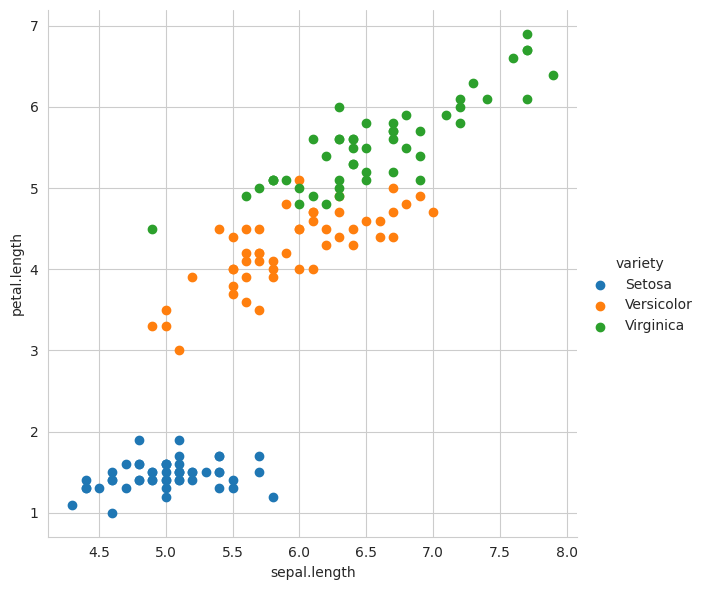

In [85]:
sns.set_style("whitegrid")

# sepal.length, petal.length are iris
# feature data height used to define
# hue store the class of iris dataset.
sns.FacetGrid(df, hue ="variety",
              height = 6).map(plt.scatter,
                              'sepal.length',
                              'petal.length').add_legend()

In [30]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [31]:
# Change variety column from str to float
df['variety'] = df['variety'].replace({
    'Setosa': 0,
    'Versicolor': 1,
    'Virginica': 2
}).astype(int)

In [32]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [33]:
# Train test Split

X = df.drop('variety', axis=1)
Y = df['variety']

In [34]:
# Convert X, Y to numpy arrays
X=X.values
Y=Y.values

In [78]:
# Train and test set split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,
                                                    train_size=0.8,
                                                    random_state=42)

In [36]:
# Convert arrays to tensor
# X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# Y labels to tensors long (int)
Y_train = torch.LongTensor(Y_train)
Y_test = torch.LongTensor(Y_test)

# Creating the DNN model

In [37]:
# Model Class that inherits from nn.Module

class Model(nn.Module):
  # Input layer (4 characteristics of iris flower)
  # Hidden layer
  # Output layer (3 species of iris)

  # Number of neurons in each layer
  def __init__(self, input_number = 4,
               hidden1_number = 8,
               hidden2_number = 4,
               output_number = 3):
    super().__init__() # initiate nn.Module

  # fc - fully connected
    self.fc1 = nn.Linear(input_number, hidden1_number)
    self.fc2 = nn.Linear(hidden1_number, hidden2_number)
    self.out = nn.Linear(hidden2_number, output_number)

  # Forward propagation
  def forward(self, X):
    # Move data through layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.out(X)

    return X




In [38]:
# Set seed for repeatability
torch.manual_seed(42)

# Create instance of Model
model = Model()

In [39]:
# Criterion for model to measure prediction error
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


In [40]:
# Epochs
epochs = 100

losses = []

for epoch in range(epochs):
  Y_predict = model.forward(X_train) # Get predicted results

  # Measure the error
  loss = criterion(Y_predict, Y_train)

  # History of losses
  losses.append(loss.detach().numpy())
  # The expression .detach().numpy() is used in PyTorch when converting a torch

  # Print progress
  if epoch % 10 ==0:
    print(f"Epoch: {epoch}, loss: {loss}")

  # Back propagation

  optimizer.zero_grad() # Clears the old gradient values
  loss.backward()
  # Performs backpropagation to calculate the new gradients of the loss
  # with respect to each parameter (weights)
  optimizer.step()
  # Uses the calculated gradients to update the model's parameters

Epoch: 0, loss: 1.4084850549697876
Epoch: 10, loss: 1.096941351890564
Epoch: 20, loss: 1.0314691066741943
Epoch: 30, loss: 0.9239533543586731
Epoch: 40, loss: 0.8214181661605835
Epoch: 50, loss: 0.7241766452789307
Epoch: 60, loss: 0.5573097467422485
Epoch: 70, loss: 0.446953684091568
Epoch: 80, loss: 0.3555295169353485
Epoch: 90, loss: 0.248922660946846


Text(0.5, 0, 'Epoch')

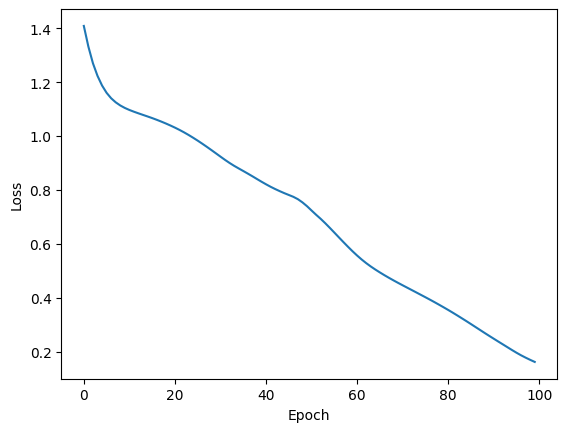

In [41]:
# Loss history plot

plt.plot(range(epochs), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

# Model evaluation

In [42]:
# Validate the model on Test Data Set

# Send test data thru model, without changing parameters
with torch.no_grad(): # Trun off back propagation
  Y_eval = model.forward(X_test)
  loss = criterion(Y_eval, Y_test)


In [43]:
loss

tensor(0.1880)

In [44]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    Y_value = model.forward(data)

    # What species of iris was pointed by the model
    print(f"({i+1}.) {str(Y_value)} \t {Y_test[i]} \t {Y_value.argmax().item()}")

    # Check if the model prediction is correct
    if Y_value.argmax().item() == Y_test[i]:
      correct += 1

print()
print(f"Number of correct predictions: {correct}")

(1.) tensor([-1.9078,  3.9821,  3.1026]) 	 1 	 1
(2.) tensor([ 5.5595,  0.7607, -7.0483]) 	 0 	 0
(3.) tensor([-8.5876,  6.4987, 12.2549]) 	 2 	 2
(4.) tensor([-1.6621,  3.9560,  2.7745]) 	 1 	 1
(5.) tensor([-2.2114,  4.3125,  3.5439]) 	 1 	 1
(6.) tensor([ 5.2900,  0.6886, -6.7096]) 	 0 	 0
(7.) tensor([ 0.6946,  2.9732, -0.4413]) 	 1 	 1
(8.) tensor([-3.6384,  4.9244,  5.5056]) 	 2 	 2
(9.) tensor([-3.2727,  4.1917,  4.9270]) 	 1 	 2
(10.) tensor([-0.2225,  3.3795,  0.8028]) 	 1 	 1
(11.) tensor([-3.0789,  4.6493,  4.7337]) 	 2 	 2
(12.) tensor([ 4.7986,  0.5805, -6.0886]) 	 0 	 0
(13.) tensor([ 5.3331,  0.6601, -6.7693]) 	 0 	 0
(14.) tensor([ 4.8813,  0.6105, -6.1915]) 	 0 	 0
(15.) tensor([ 5.2649,  0.7080, -6.6744]) 	 0 	 0
(16.) tensor([-1.2551,  4.1010,  2.2573]) 	 1 	 1
(17.) tensor([-5.6784,  5.2744,  8.2449]) 	 2 	 2
(18.) tensor([-0.6053,  3.3649,  1.3026]) 	 1 	 1
(19.) tensor([-1.7036,  3.8103,  2.8112]) 	 1 	 1
(20.) tensor([-5.6838,  5.1729,  8.2380]) 	 2 	 2
(21.) ten

In [45]:
# Accuracy
# FP, TP, FN, TN
# specificity,

In [46]:
# Evaluating New Data
iris_new = torch.tensor([4.6, 3.2, 1.4, 0.8])

In [47]:
with torch.no_grad():
  print(model(iris_new))
  print(model(iris_new).argmax())

tensor([ 4.9164,  0.6437, -6.2322])
tensor(0)


In [48]:
iris_new_2 = torch.tensor([6.2,	3.4,	5.4,	2.3])

In [49]:
with torch.no_grad():
  print(model(iris_new_2))
  print(model(iris_new_2).argmax())

tensor([-3.9565,  4.8835,  5.9235])
tensor(2)


# Save DNN model

In [50]:
# Save
torch.save(model.state_dict(), 'iris_DNN_model.pt')

In [51]:
# Load
new_model = Model()
new_model.load_state_dict(torch.load('iris_DNN_model.pt'))

<All keys matched successfully>

In [52]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=4, bias=True)
  (out): Linear(in_features=4, out_features=3, bias=True)
)

# Scatterplot

In [75]:
# style used as a theme of graph
# for example if we want black
# graph with grid then write "darkgrid"
sns.set_style("whitegrid")

# sepal_length, petal_length are iris
# feature data height used to define
# Height of graph whereas hue store the
# class of iris dataset.
sns.FacetGrid(pd.DataFrame(X_train), hue ="species",
              height = 6).map(plt.scatter,
                              'sepal_length',
                              'petal_length').add_legend()

KeyError: 'species'

In [76]:
pd.DataFrame(X_train)

,0,1,2,3
0,4.6,3.6,1.0,0.2
1,5.7,4.4,1.5,0.4
2,6.7,3.1,4.4,1.4
3,4.8,3.4,1.6,0.2
4,4.4,3.2,1.3,0.2
...,...,...,...,...
115,6.1,2.8,4.0,1.3
116,4.9,2.5,4.5,1.7
117,5.8,4.0,1.2,0.2
118,5.8,2.6,4.0,1.2


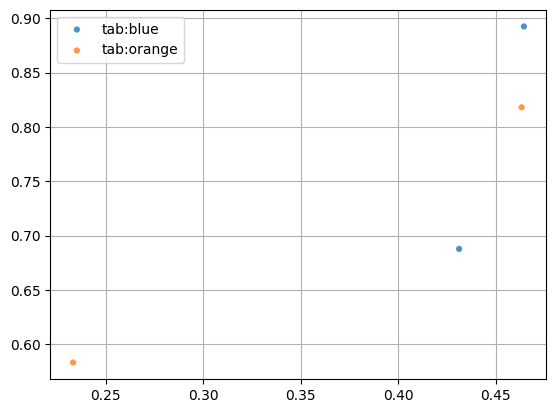

In [68]:
fig, ax = plt.subplots()
for color in ['tab:blue', 'tab:orange']:
    n = 2
    x, y = np.random.rand(2, n)
    scale = 20.0
    ax.scatter(x, y, c=color, s=scale, label=color,
               alpha=0.8, edgecolors='none')

ax.legend()
ax.grid(True)

plt.show()